# Initialize MODIS Snow Phenology

This notebook does two things in order:

**Phase 1 — Tile Selection**: Downloads the MODIS 36×18 sinusoidal tile grid, intersects with a land mask, and writes `processing/tile_data/tile_processing_status.geojson` — the tile registry used by all downstream processing.

**Phase 2 — Icechunk Store Creation**: Creates an empty Zarr v3 store (with ShardingCodec) on Azure Blob Storage via Icechunk, ready to receive tile writes from GitHub Actions.

---
Run Phase 1 first. Edit the GeoJSON to manually mark any tiles you want to skip before running Phase 2 or any batch jobs.

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import geodatasets
import xarray as xr
import dask
import zarr
import icechunk
import rioxarray
import matplotlib.pyplot as plt
from pathlib import Path

import sys
sys.path.insert(0, str(Path('..').resolve()))
from modis_snow_phenology import processing, Config

config = Config("config/config_v1.txt")
REPO_ROOT = Path('..').resolve()

## Phase 1: Tile Selection

Build the `tile_processing_status.geojson` GeoDataFrame with one row per MODIS tile.

In [2]:
# Download MODIS sinusoidal tile grid (648 tiles: 36h × 18v)
modis_grid_gdf = gpd.read_file(
    'zip+http://book.ecosens.org/wp-content/uploads/2016/06/modis_grid.zip'
    '!modis_sinusoidal_grid_world.shp'
)
print(f'MODIS grid: {len(modis_grid_gdf)} tiles, CRS: {modis_grid_gdf.crs}')

MODIS grid: 648 tiles, CRS: PROJCS["Sinusoidal_Sanson_Flamsteed",GEOGCS["GCS_Unknown",DATUM["unknown",SPHEROID["Unknown",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [3]:
# set initial columns and types
modis_grid_gdf['h'] = modis_grid_gdf['h'].astype(int)
modis_grid_gdf['v'] = modis_grid_gdf['v'].astype(int)
modis_grid_gdf['tile'] = modis_grid_gdf.apply(lambda row: f"h{int(row['h']):02d}v{int(row['v']):02d}", axis=1)

# Set initial processing status
modis_grid_gdf['land'] = False
modis_grid_gdf['processing_status'] = 'skip' # options are 'skip', 'unprocessed', 'processed', 'failure'
modis_grid_gdf['notes'] = 'Skip because no land intersection.'

# order columns
modis_grid_gdf = modis_grid_gdf[['tile', 'h', 'v', 'land', 'processing_status', 'notes', 'geometry']]

In [4]:
# optional cell, might need to add some handling for microsoft planetary computer APIError: The request exceeded the maximum allowed time, please try again. If the issue persists, please contact planetarycomputer@microsoft.com.
 
# import planetary_computer
# import pystac_client

# catalog = pystac_client.Client.open(
#     "https://planetarycomputer.microsoft.com/api/stac/v1/",
#     modifier=planetary_computer.sign_inplace,
# )


# def how_many_MOD10A2_scenes(h, v):
#     search = catalog.search(
#         collections=[f"modis-10A2-061"],
#         query={
#             "modis:vertical-tile": {"eq": v},
#             "modis:horizontal-tile": {"eq": h},
#         },
#     )
#     return len(search.item_collection())

# modis_grid_gdf['num_MOD10A2_scenes'] = modis_grid_gdf.apply(lambda row: how_many_MOD10A2_scenes(row['h'], row['v']), axis=1)
# modis_grid_gdf = modis_grid_gdf[['tile', 'h', 'v', 'num_MOD10A2_scenes', 'land', 'processing_status', 'notes', 'geometry']]


In [5]:
# Load Natural Earth land mask and reproject to MODIS sinusoidal CRS, set land bool column
land_proj_gdf = gpd.read_file(geodatasets.get_url('naturalearth land')).to_crs(modis_grid_gdf.crs)
land_proj_gs = gpd.GeoSeries(land_proj_gdf.union_all(), crs=modis_grid_gdf.crs)
land_mask_s = modis_grid_gdf.intersects(land_proj_gs.union_all())

modis_grid_gdf['land'] = land_mask_s.values
modis_grid_gdf.loc[modis_grid_gdf['land'], 'processing_status'] = 'unprocessed'
modis_grid_gdf

,tile,h,v,land,processing_status,notes,geometry
0,h00v17,0,17,False,skip,Skip because no land intersection.,"POLYGON ((-19649629.667 -10010000, -20020000 -..."
1,h01v17,1,17,False,skip,Skip because no land intersection.,"POLYGON ((-18538518.667 -10010000, -18908889 -..."
2,h02v17,2,17,False,skip,Skip because no land intersection.,"POLYGON ((-17427407.667 -10010000, -17797778 -..."
3,h03v17,3,17,False,skip,Skip because no land intersection.,"POLYGON ((-16316296.667 -10010000, -16686667 -..."
4,h04v17,4,17,False,skip,Skip because no land intersection.,"POLYGON ((-15205185.667 -10010000, -15575556 -..."
...,...,...,...,...,...,...,...
643,h31v00,31,0,False,skip,Skip because no land intersection.,"POLYGON ((14794811.333 8878887, 14424441 88788..."
644,h32v00,32,0,False,skip,Skip because no land intersection.,"POLYGON ((15905922.333 8878887, 15535552 88788..."
645,h33v00,33,0,False,skip,Skip because no land intersection.,"POLYGON ((17017033.333 8878887, 16646663 88788..."
646,h34v00,34,0,False,skip,Skip because no land intersection.,"POLYGON ((18128144.333 8878887, 17757774 88788..."


In [6]:
# manually exclude index 600 (h24v1), no MOD10A2 data available for this tile (almost all ocean anyway)
modis_grid_gdf.loc[600, 'processing_status'] = 'skip'
modis_grid_gdf.loc[600, 'notes'] = 'Skip because no MOD10A2 data available.'

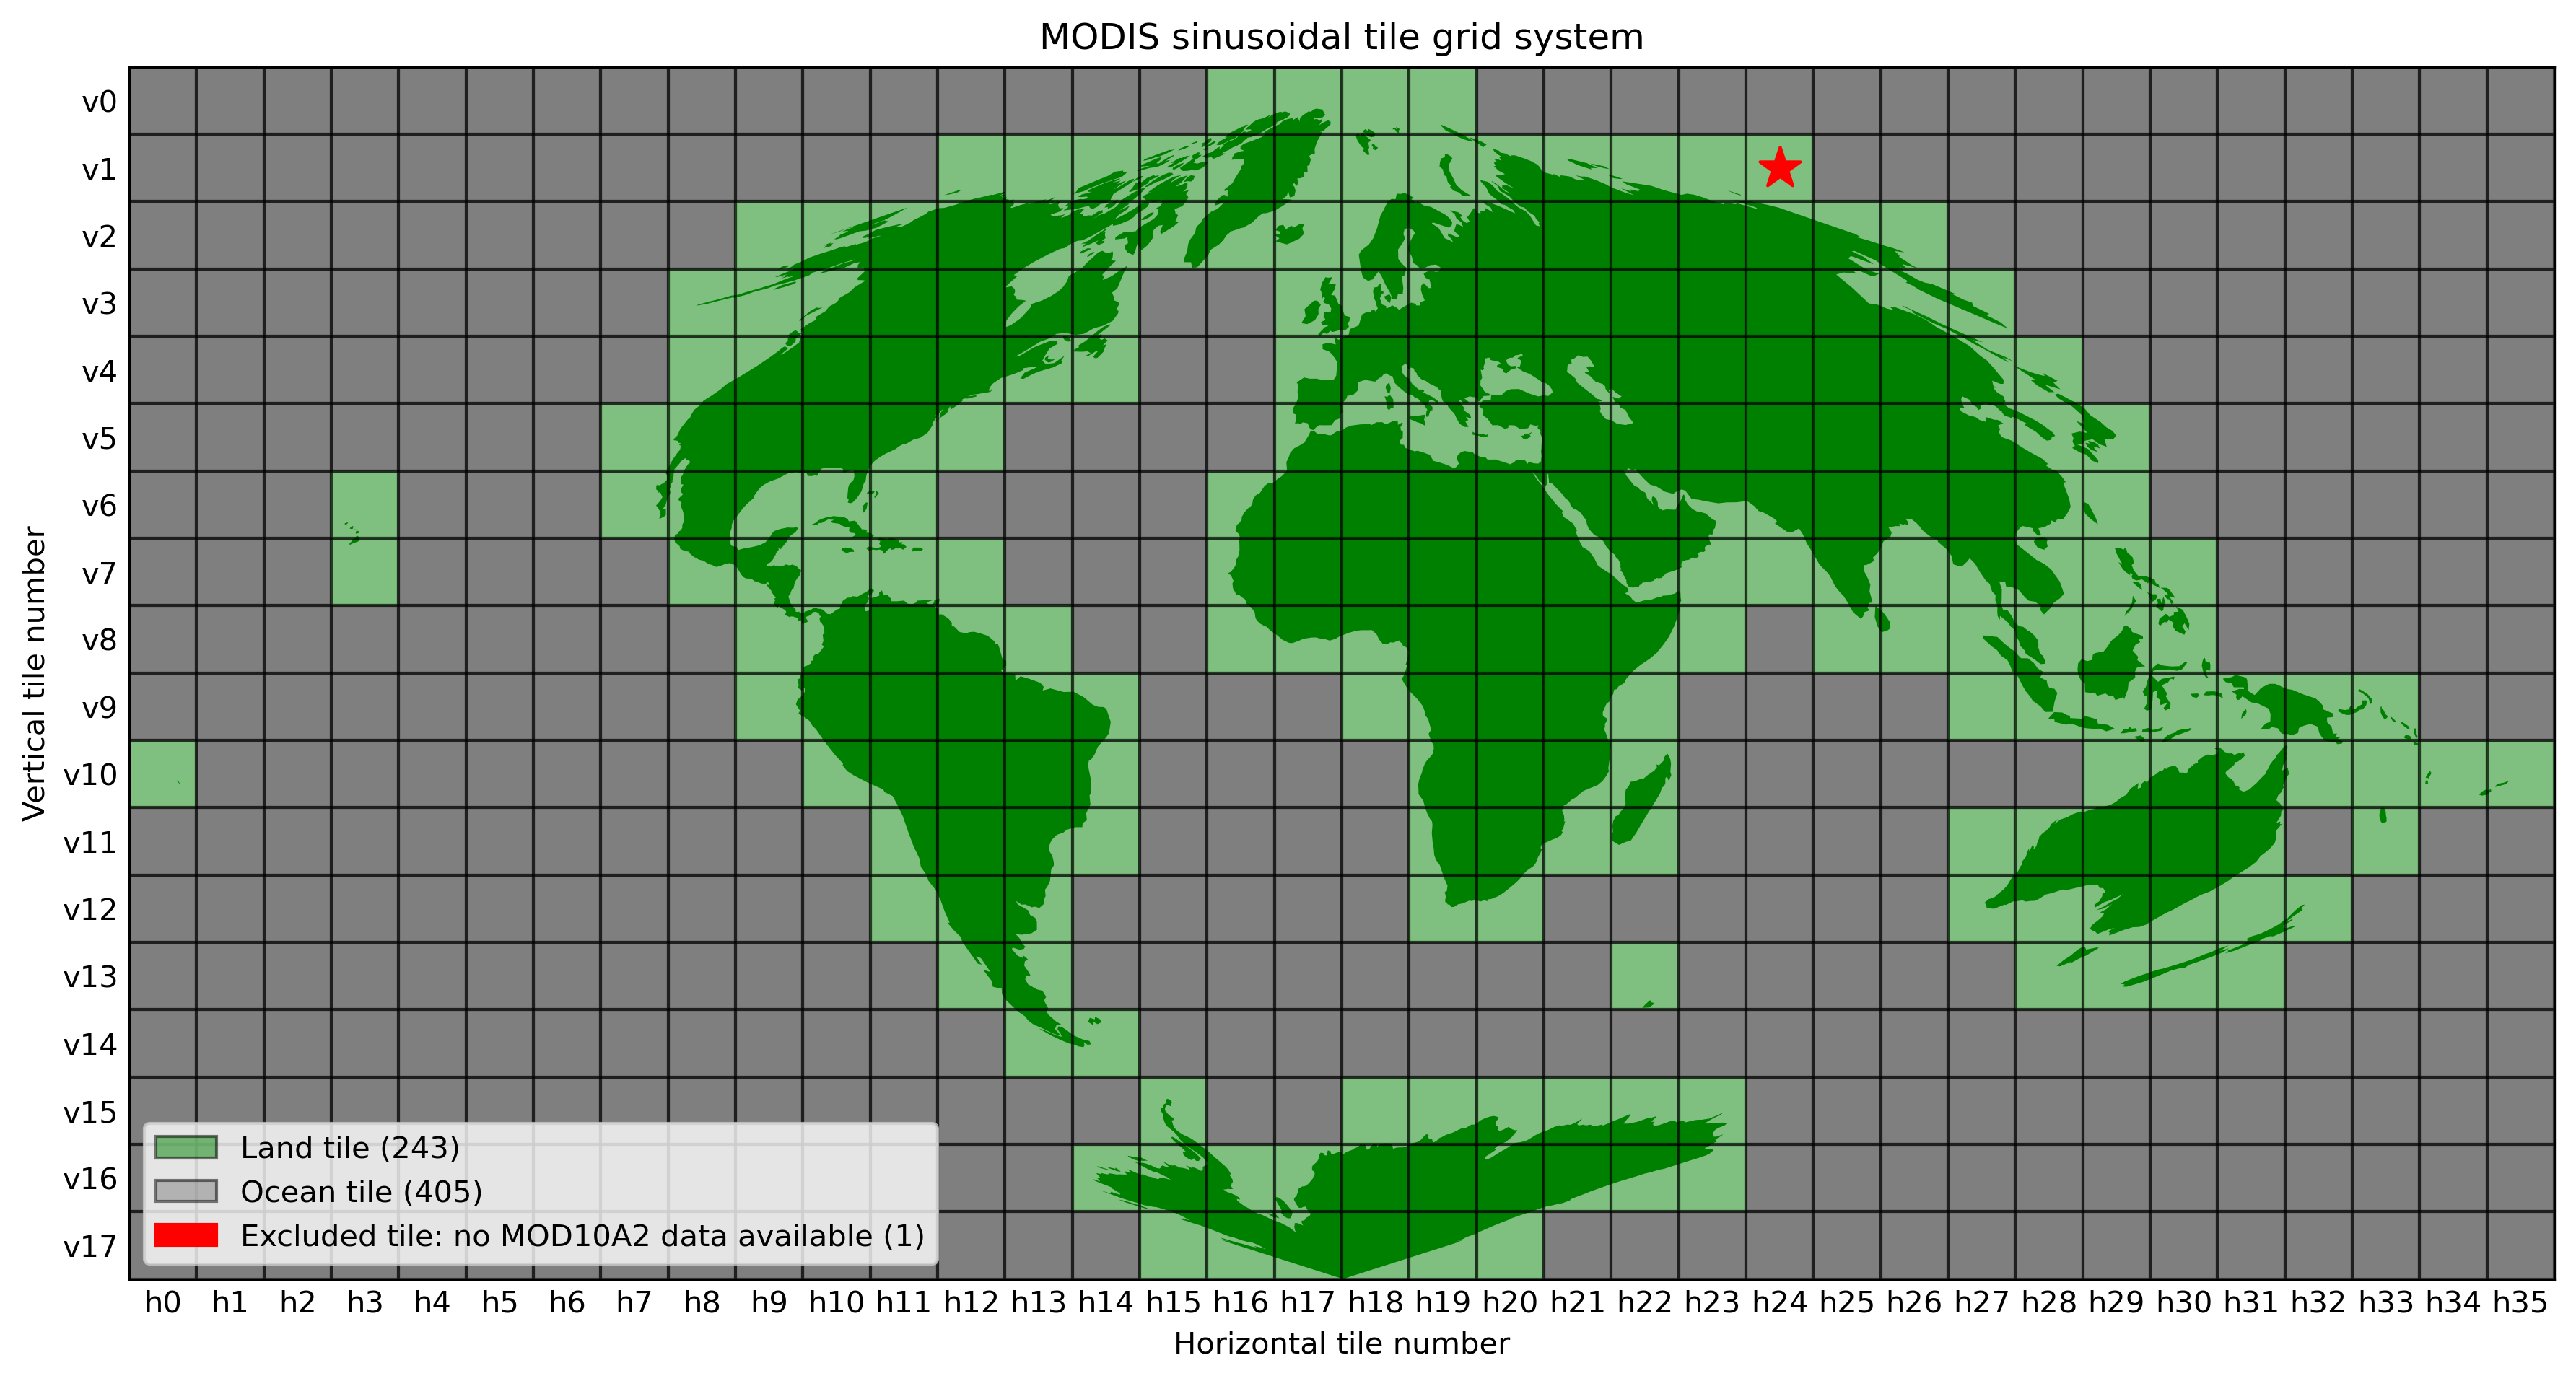

In [7]:
f, ax = plt.subplots(figsize=(12,7),dpi=300)

land_proj_gdf.plot(ax=ax, color='green',zorder=0)
modis_grid_gdf.plot(ax=ax, facecolor=modis_grid_gdf['land'].map({True: 'green', False: 'none'}), edgecolor='black', alpha=0.5, zorder=1)

# plot asterisk at centroid of each tile manually excluded
excluded_tiles = modis_grid_gdf[modis_grid_gdf['notes'] == 'Skip because no MOD10A2 data available.']
excluded_tiles_centroids = excluded_tiles.geometry.centroid
ax.scatter(excluded_tiles_centroids.x, excluded_tiles_centroids.y, marker='*', color='red', s=200, label='Manually excluded tile (no data available)', zorder=2)


ax.set_title(f'MODIS sinusoidal tile grid system')
ax.set_xlabel('Horizontal tile number')
ax.set_ylabel('Vertical tile number')

# create tick labels for h and v values, using the mean centroid of the tiles in each row/column to position the ticks
h_values = sorted(modis_grid_gdf['h'].unique())
v_values = sorted(modis_grid_gdf['v'].unique(), reverse=True)

h_coords = [modis_grid_gdf[modis_grid_gdf['h'] == h].geometry.centroid.x.mean() for h in h_values]
v_coords = [modis_grid_gdf[modis_grid_gdf['v'] == v].geometry.centroid.y.mean() for v in v_values]

ax.set_xticks(h_coords)
ax.set_xticklabels([f'h{h}' for h in h_values])
ax.set_yticks(v_coords)
ax.set_yticklabels([f'v{v}' for v in v_values])

ax.tick_params(axis='both', which='both', length=0)

ax.set_xlim(modis_grid_gdf.total_bounds[0], modis_grid_gdf.total_bounds[2])
ax.set_ylim(modis_grid_gdf.total_bounds[1], modis_grid_gdf.total_bounds[3])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.5, edgecolor='black', label=f'Land tile ({modis_grid_gdf[modis_grid_gdf["land"] == True].shape[0]})'),
                   Patch(facecolor='grey', alpha=0.5, edgecolor='black', label=f'Ocean tile ({modis_grid_gdf[modis_grid_gdf["land"] == False].shape[0]})'),
                   Patch(facecolor='red', edgecolor='red', label=f'Excluded tile: no MOD10A2 data available ({excluded_tiles.shape[0]})')]
ax.legend(handles=legend_elements, loc='lower left')

f.tight_layout()

In [8]:
# Save GeoJSON tile registry
config.tile_status_path.parent.mkdir(parents=True, exist_ok=True)
modis_grid_gdf.to_file(config.tile_status_path, driver='GeoJSON')
print(f'Saved {len(modis_grid_gdf)} tile records to {config.tile_status_path}')

Saved 648 tile records to /home/eric/repos/MODIS_snow_phenology/processing/tile_data/tile_processing_status.geojson


---
## Phase 2: Icechunk Store Creation

Creates an empty Zarr v3 store on Azure Blob Storage using Icechunk.
The store is metadata-only at this point — tile data is written by GitHub Actions.

Requires: `AZURE_STORAGE_ACCOUNT` and `AZURE_STORAGE_SAS_TOKEN` environment variables.

In [9]:
# Get MODIS sinusoidal grid x/y coordinates from STAC
# This fetches one MODIS scene to extract the full coordinate arrays
print('Fetching MODIS grid coordinates from Planetary Computer STAC...')
modis_full_grid = processing.get_modis_MOD10A2_full_grid()
y_coords = modis_full_grid.y.values
x_coords = modis_full_grid.x.values
print(f'Grid shape: y={len(y_coords)}, x={len(x_coords)}')
print(f'y range: [{y_coords.min():.1f}, {y_coords.max():.1f}]')
print(f'x range: [{x_coords.min():.1f}, {x_coords.max():.1f}]')

Fetching MODIS grid coordinates from Planetary Computer STAC...
Grid shape: y=43200, x=86400
y range: [-10007323.0, 10007323.0]
x range: [-20014877.7, 20014877.7]


In [10]:
# Build empty xarray template dataset
water_years = np.arange(config.wy_start, config.wy_end + 1)
fill_value = np.iinfo(np.int16).min  # -32768

shape = (len(water_years), len(y_coords), len(x_coords))
print(f'Store shape: {shape} ({np.prod(shape) * 2 / 1e9:.1f} GB uncompressed per variable)')

ds_template = xr.Dataset(
    {
        'SAD_DOWY': xr.DataArray(
            dask.array.full(shape, fill_value=fill_value, chunks=(1, 2400, 2400), dtype=np.int16),
            dims=('water_year', 'y', 'x'),
        ),
        'SDD_DOWY': xr.DataArray(
            dask.array.full(shape, fill_value=fill_value, chunks=(1, 2400, 2400), dtype=np.int16),
            dims=('water_year', 'y', 'x'),
        ),
        'max_consec_snow_days': xr.DataArray(
            dask.array.full(shape, fill_value=fill_value, chunks=(1, 2400, 2400), dtype=np.int16),
            dims=('water_year', 'y', 'x'),
        ),
    },
    coords={
        'water_year': water_years,
        'y': y_coords,
        'x': x_coords,
    },
)

# Add CRS (GeoZarr convention: spatial_ref variable + grid_mapping attribute)
modis_crs = modis_full_grid.rio.crs
ds_template = ds_template.rio.write_crs(modis_crs)
for var in ds_template.data_vars:
    ds_template[var].attrs['grid_mapping'] = 'spatial_ref'

# Add metadata
ds_template.water_year.attrs['description'] = (
    'Water year. Northern hemisphere: Oct 1 – Sep 30 (e.g. WY2015 = 2014-10-01 to 2015-09-30). '
    'Southern hemisphere: Apr 1 – Mar 31 (e.g. WY2015 = 2015-04-01 to 2016-03-31).'
)
ds_template.attrs['title'] = 'Global MODIS Snow Phenology'
ds_template.attrs['description'] = (
    'Snow appearance date (SAD), snow disappearance date (SDD), and maximum consecutive snow days '
    'derived from MODIS MOD10A2 8-day maximum snow extent product. '
    'Cloud filling follows Wrzesien et al. 2019.'
)
ds_template.attrs['source'] = 'MODIS MOD10A2.061 via Microsoft Planetary Computer'
ds_template.attrs['Conventions'] = 'CF-1.8'

for var in ['SAD_DOWY', 'SDD_DOWY']:
    ds_template[var].attrs['units'] = 'day of water year'
    ds_template[var].attrs['_FillValue'] = fill_value
ds_template['max_consec_snow_days'].attrs['units'] = 'number of days' # avoiding "days" which CF convention suggests for time durations and mask_and_scale=True misinterprets as int64
ds_template['max_consec_snow_days'].attrs['_FillValue'] = fill_value

ds_template

Store shape: (10, 43200, 86400) (74.6 GB uncompressed per variable)


<xarray.Dataset> Size: 224GB
Dimensions:               (water_year: 10, y: 43200, x: 86400)
Coordinates:
  * water_year            (water_year) int64 80B 2015 2016 2017 ... 2023 2024
  * y                     (y) float64 346kB 1.001e+07 1.001e+07 ... -1.001e+07
  * x                     (x) float64 691kB -2.001e+07 -2.001e+07 ... 2.001e+07
    spatial_ref           int64 8B 0
Data variables:
    SAD_DOWY              (water_year, y, x) int16 75GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
    SDD_DOWY              (water_year, y, x) int16 75GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
    max_consec_snow_days  (water_year, y, x) int16 75GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
Attributes:
    title:        Global MODIS Snow Phenology
    description:  Snow appearance date (SAD), snow disappearance date (SDD), ...
    source:       MODIS MOD10A2.061 via Microsoft Planetary Computer
    Conventions:  CF-1.8

In [ ]:
# clean up any existing store at the target location before creating new one
remove_existing_store = False  # set to True to delete existing store and start fresh (warning: this will delete all existing data in the store!)
if remove_existing_store == True:
    import adlfs

    fs = adlfs.AzureBlobFileSystem(
        account_name=config.azure_storage_account,
        sas_token=config.azure_storage_sas_token,
    )
    prefix_path = f"{config.azure_container}/{config.icechunk_prefix}"
    if fs.exists(prefix_path):
        fs.rm(prefix_path, recursive=True)
        print(f"Deleted existing store at {prefix_path}")
    else:
        print("No existing store found, nothing to delete")

Deleted existing store at snowmelt/modis_snow_phenology/modis_snow_phenology_v1


In [12]:
# Create Icechunk repository on Azure Blob Storage
storage = icechunk.azure_storage(
    account=config.azure_storage_account,
    container=config.azure_container,
    prefix=config.icechunk_prefix,
    sas_token=config.azure_storage_sas_token,
)

repo = icechunk.Repository.create(storage)

In [13]:
# Write empty template to the Icechunk store
session = repo.writable_session('main')

data_vars = ['SAD_DOWY', 'SDD_DOWY', 'max_consec_snow_days']
encoding = {
    var: {
        'shards': tuple(config.shard_shape),         # (1, 2400, 2400)
        'chunks': tuple(config.inner_chunk_shape),   # (1, 600, 600)
        'compressors': [zarr.codecs.BloscCodec(cname='zstd', clevel=5)],
        'fill_value': fill_value,
        'dtype': 'int16',
    }
    for var in data_vars
}

ds_template.to_zarr(
    session.store,
    mode='w',
    zarr_format=3,
    encoding=encoding,
    compute=False,
    write_empty_chunks=False,
)

snapshot_id = session.commit('Initialize store: empty template, WY2015-2024')
print(f'Store initialized. Snapshot ID: {snapshot_id}')

Store initialized. Snapshot ID: HXZWW48RBX2RAV5DY4B0


In [14]:
session_ro = repo.readonly_session('main')
ds_verify = xr.open_zarr(session_ro.store, zarr_format=3, consolidated=False, decode_coords='all')
print(ds_verify)
print('CRS:', ds_verify.rio.crs)

<xarray.Dataset> Size: 448GB
Dimensions:               (water_year: 10, y: 43200, x: 86400)
Coordinates:
  * water_year            (water_year) int64 80B 2015 2016 2017 ... 2023 2024
  * y                     (y) float64 346kB 1.001e+07 1.001e+07 ... -1.001e+07
  * x                     (x) float64 691kB -2.001e+07 -2.001e+07 ... 2.001e+07
    spatial_ref           int64 8B ...
Data variables:
    SAD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 600, 600), meta=np.ndarray>
    SDD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 600, 600), meta=np.ndarray>
    max_consec_snow_days  (water_year, y, x) float32 149GB dask.array<chunksize=(1, 600, 600), meta=np.ndarray>
Attributes:
    title:        Global MODIS Snow Phenology
    description:  Snow appearance date (SAD), snow disappearance date (SDD), ...
    source:       MODIS MOD10A2.061 via Microsoft Planetary Computer
    Conventions:  CF-1.8
CRS: PROJCS["unnamed",GEOGCS["Unkn